In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
BASE = Path("outputs")
RUNS = BASE / "runs"
PRED = BASE / "predictions_fold"

# Display setup
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.titlesize"] = 14

In [ ]:
# Load all per-file metrics
all_metrics = []
for fold_dir in sorted(BASE.glob("predictions_fold*")):
    csv_path = fold_dir / "per_file_metrics.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df["fold"] = fold_dir.name.replace("predictions_fold", "")
        all_metrics.append(df)

metrics_df = pd.concat(all_metrics, ignore_index=True)
metrics_df.head()

# event_f1 -> how accurately the model detects swallow events (higher = better)
# event_precision -> % of detected events that were *actually* swallows
# event_recall -> % of real swallows the model successfully found
# count_mae -> mean absolute error between true vs predicted event counts
# onset_mae_sec -> average timing error for swallow onset (in seconds)

,file,event_f1,event_precision,event_recall,count_mae,count_mape_%,onset_mae_sec,fold
0,data/audio/skylear_4/1.wav,0.0,0,0.0,5.0,100.0,NaN,0
1,data/audio/skylear_4/2.wav,0.0,0,0.0,18.0,100.0,NaN,0
2,data/audio/skylear_3/1.wav,0.0,0,0.0,20.0,100.0,NaN,1
3,data/audio/skylear_3/2.wav,0.0,0,0.0,9.0,100.0,NaN,1
4,data/audio/skylear_2/1.wav,0.0,0,0.0,41.0,100.0,NaN,2


,fold,event_f1,event_precision,event_recall,count_mae,onset_mae_sec
0,0,0.0,0.0,0.0,11.5,NaN
1,1,0.0,0.0,0.0,14.5,NaN
2,2,0.0,0.0,0.0,25.0,NaN
3,3,0.0,0.0,0.0,20.5,NaN
4,4,0.0,0.0,0.0,29.5,NaN


/tmp/ipykernel_13344/716199730.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="fold", y="event_f1", data=agg, palette="crest")


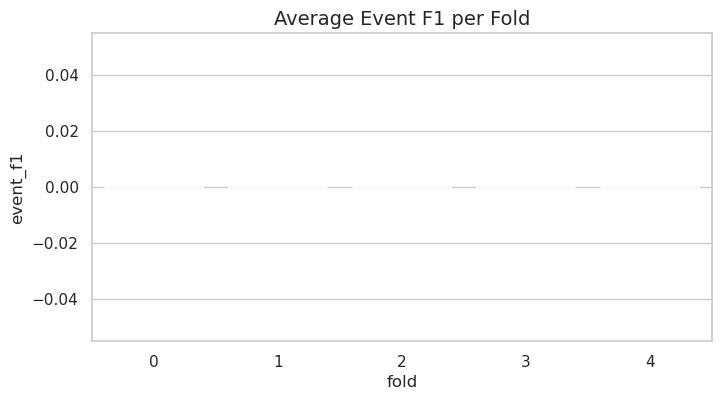

In [ ]:
# Aggregate metrics
agg = (
    metrics_df.groupby("fold")[["event_f1", "event_precision", "event_recall", "count_mae", "onset_mae_sec"]]
    .mean()
    .reset_index()
)
display(agg)

plt.figure(figsize=(8, 4))
sns.barplot(x="fold", y="event_f1", data=agg, palette="crest")
plt.title("Average Event F1 per Fold")
plt.show()

# Each bar shows how well that fold performed overall.
# Similar F1s -> consistent model performance.
# Big variance -> model depends heavily on specific subjects or sessions.

In [ ]:
# Inspect best/worst files
print("Lowest F1 files:")
display(metrics_df.sort_values("event_f1").head(5))

print("Highest F1 files:")
display(metrics_df.sort_values("event_f1", ascending=False).head(5))
# "Lowest F1" -> bad predictions (likely false positives or missed events)
# "Highest F1" -> clean detections and well-separated swallows
# Reviewing those files helps debug model weaknesses (e.g., noisy mic, speaker overlap)


Lowest F1 files:


,file,event_f1,event_precision,event_recall,count_mae,count_mape_%,onset_mae_sec,fold
0,data/audio/skylear_4/1.wav,0.0,0,0.0,5.0,100.0,NaN,0
1,data/audio/skylear_4/2.wav,0.0,0,0.0,18.0,100.0,NaN,0
2,data/audio/skylear_3/1.wav,0.0,0,0.0,20.0,100.0,NaN,1
3,data/audio/skylear_3/2.wav,0.0,0,0.0,9.0,100.0,NaN,1
4,data/audio/skylear_2/1.wav,0.0,0,0.0,41.0,100.0,NaN,2


Highest F1 files:


,file,event_f1,event_precision,event_recall,count_mae,count_mape_%,onset_mae_sec,fold
0,data/audio/skylear_4/1.wav,0.0,0,0.0,5.0,100.0,NaN,0
1,data/audio/skylear_4/2.wav,0.0,0,0.0,18.0,100.0,NaN,0
2,data/audio/skylear_3/1.wav,0.0,0,0.0,20.0,100.0,NaN,1
3,data/audio/skylear_3/2.wav,0.0,0,0.0,9.0,100.0,NaN,1
4,data/audio/skylear_2/1.wav,0.0,0,0.0,41.0,100.0,NaN,2


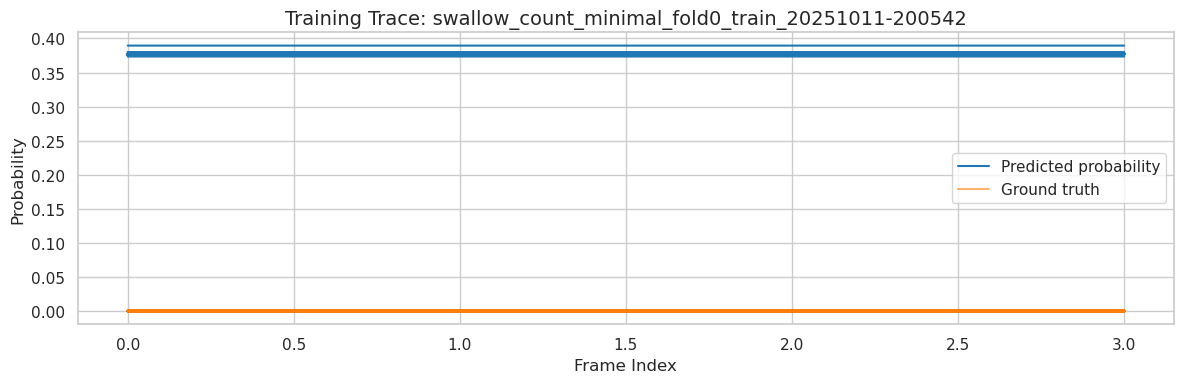

In [ ]:
# Load training trace example
trace_dir = RUNS / "swallow_count_minimal_fold0_train_20251011-200542" / "traces"
trace_file = trace_dir / "epoch005_batch4.npz"

data = np.load(trace_file)
probs = data["probs"].squeeze()
labels = data["labels"].squeeze()

plt.figure(figsize=(12, 4))
plt.plot(probs, label="Predicted probability", color="tab:blue")
plt.plot(labels, label="Ground truth", color="tab:orange", alpha=0.6)
plt.title(f"Training Trace: {trace_file.parent.parent.name}")
plt.xlabel("Frame Index")
plt.ylabel("Probability")

# Only show unique legend entries
handles, labels_ = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

# "Ground truth" means:
#   The real labeled swallows - e.g: when a human or algorithm annotated where
#   swallows occurred. It's what the model is *supposed* to learn.
#
# Blue line near orange spikes -> model correctly predicts swallows.
# Blue false peaks -> false positives (model “hallucinates” a swallow).
# Flat blue line where orange rises -> false negatives (missed swallows).

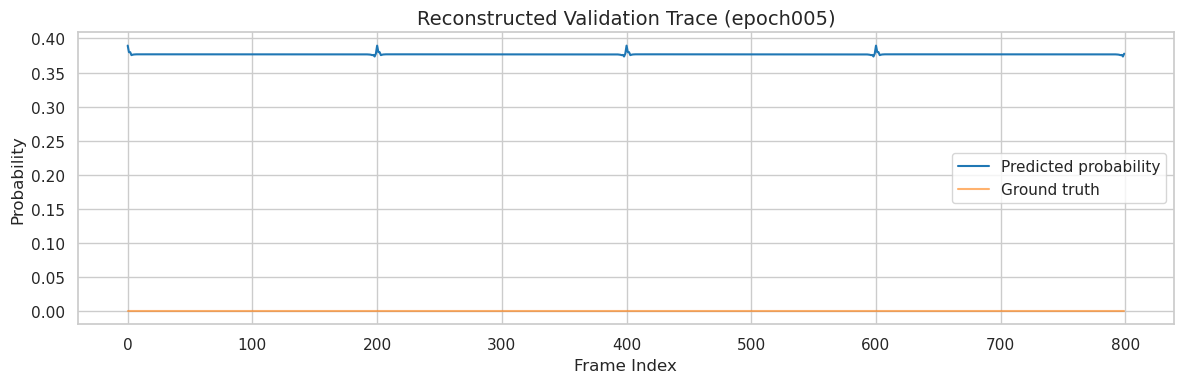

In [8]:
trace_dir = Path("outputs/runs/swallow_count_minimal_fold0_train_20251011-200542/traces")
epoch = "epoch005"

# Load all batch files for that epoch
files = sorted(trace_dir.glob(f"{epoch}_batch*.npz"))

all_probs, all_labels = [], []
for f in files:
    d = np.load(f)
    all_probs.append(d["probs"].reshape(-1))
    all_labels.append(d["labels"].reshape(-1))

probs = np.concatenate(all_probs)
labels = np.concatenate(all_labels)

plt.figure(figsize=(12, 4))
plt.plot(probs, label="Predicted probability", color="tab:blue")
plt.plot(labels, label="Ground truth", color="tab:orange", alpha=0.6)
plt.title(f"Reconstructed Validation Trace ({epoch})")
plt.xlabel("Frame Index")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()


📁 Fold traces: outputs/runs/swallow_count_minimal_fold1_train_20251011-200811/traces


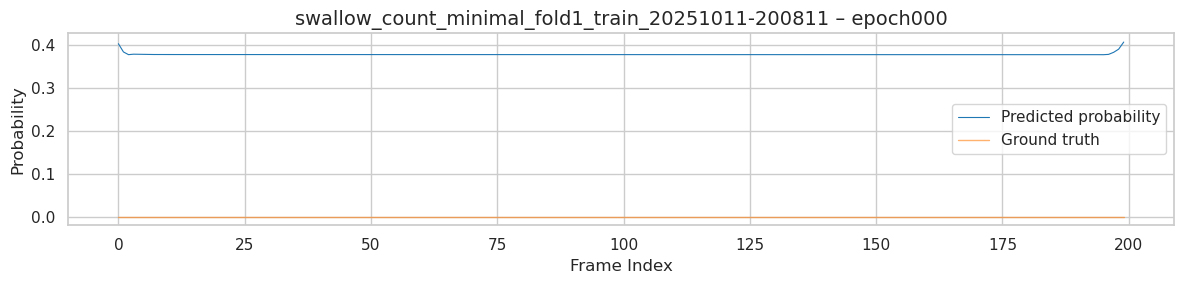

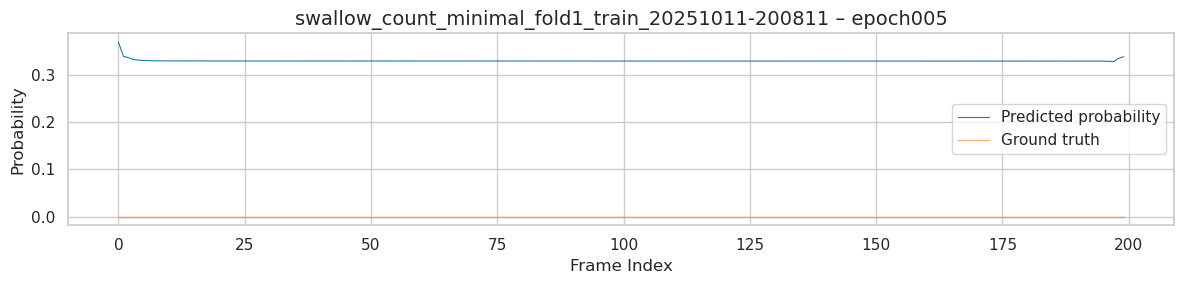

📁 Fold traces: outputs/runs/swallow_count_minimal_fold0_train_20251011-200542/traces


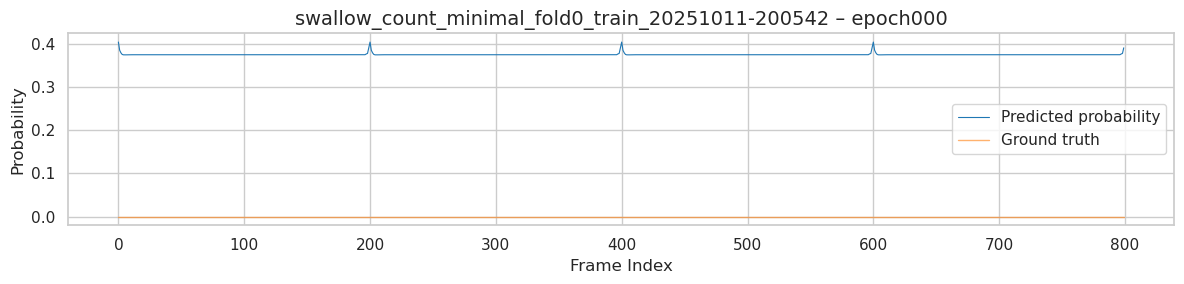

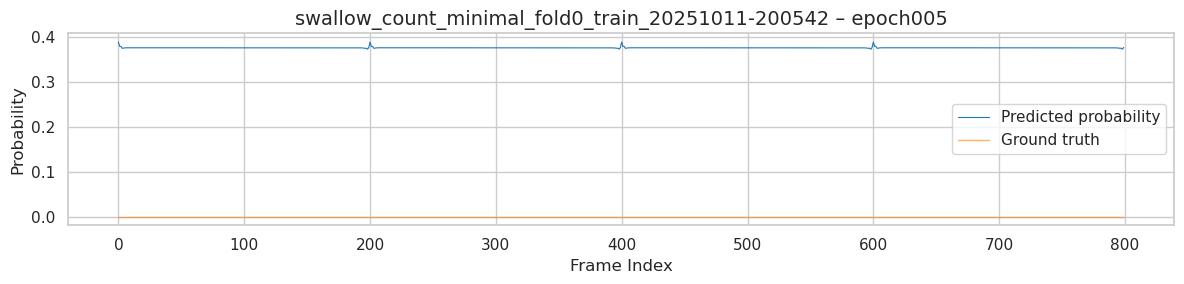

📁 Fold traces: outputs/runs/swallow_count_minimal_fold2_train_20251011-201040/traces


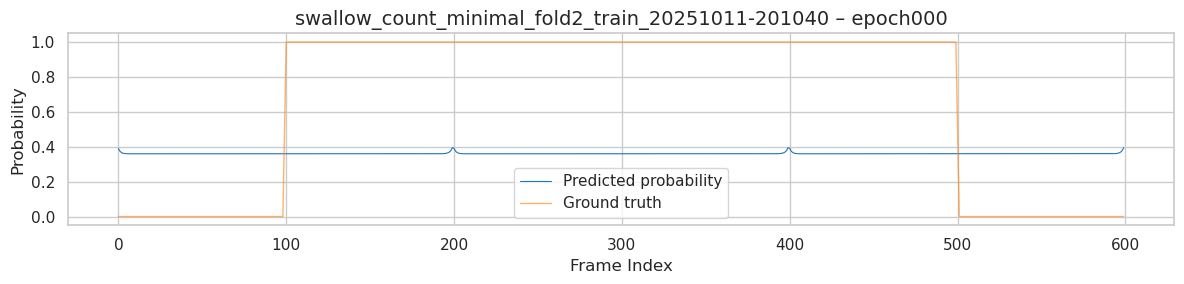

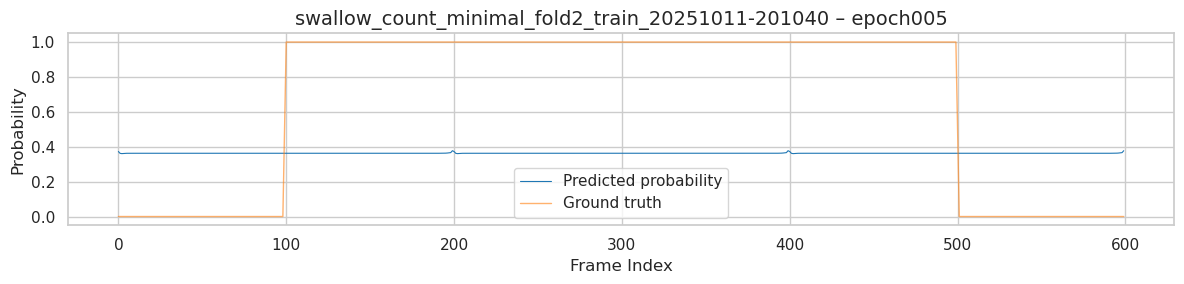

📁 Fold traces: outputs/runs/swallow_count_minimal_fold4_train_20251011-201557/traces


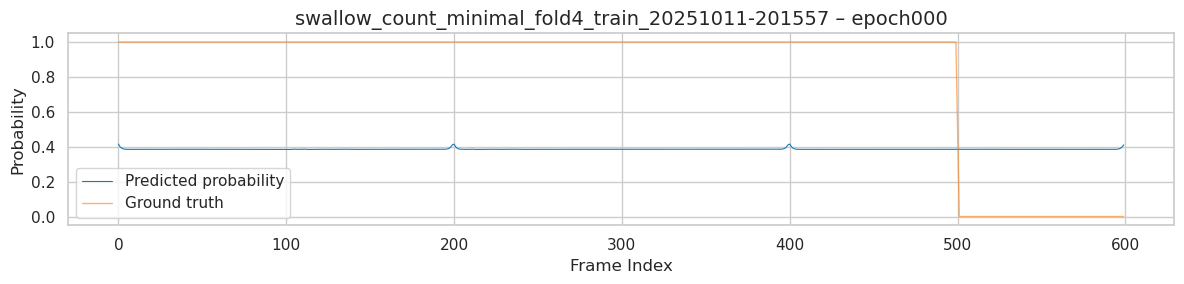

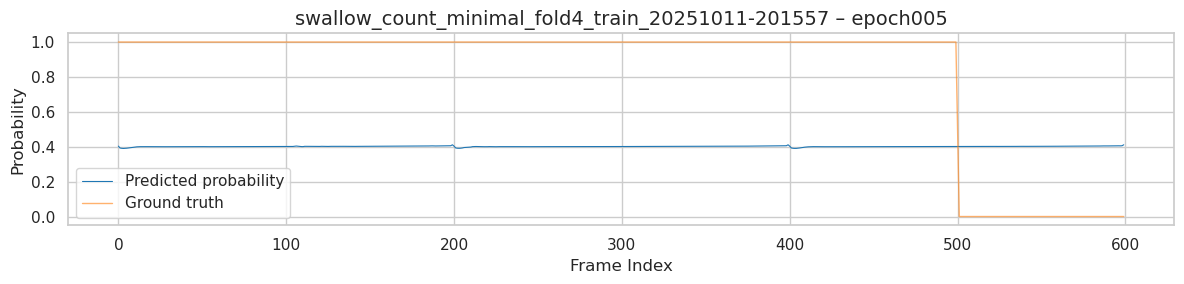

📁 Fold traces: outputs/runs/swallow_count_minimal_fold3_train_20251011-201322/traces


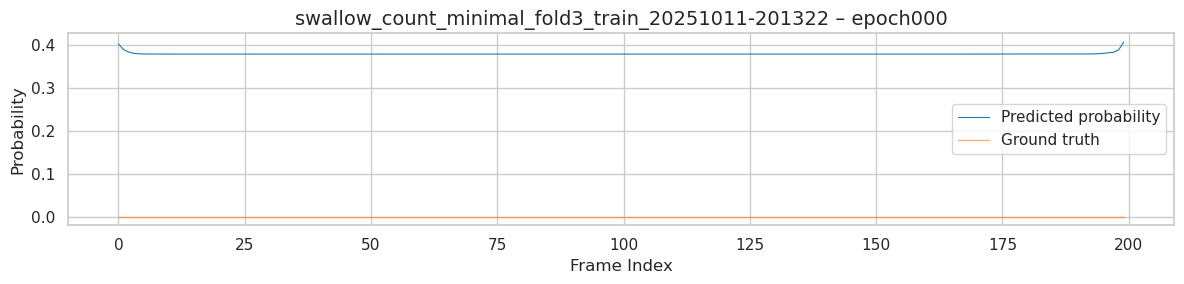

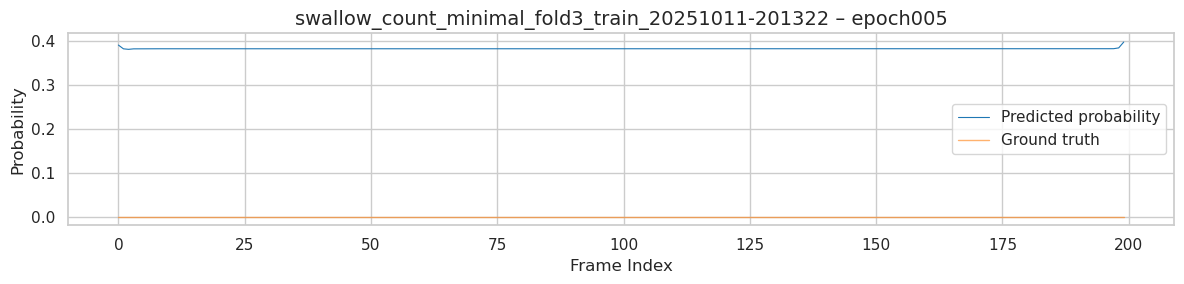

In [10]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

BASE = Path("outputs/runs")

for trace_dir in BASE.glob("swallow_count_minimal_fold*_train_*/traces"):
    print(f"📁 Fold traces: {trace_dir}")
    epoch_groups = {}

    # --- Group by epoch ---
    for f in trace_dir.glob("epoch*_batch*.npz"):
        epoch = f.stem.split("_batch")[0]
        epoch_groups.setdefault(epoch, []).append(f)

    # --- Combine + Plot ---
    for epoch, files in sorted(epoch_groups.items()):
        files = sorted(files)
        all_probs, all_labels = [], []

        for f in files:
            d = np.load(f)
            all_probs.append(d["probs"].reshape(-1))
            all_labels.append(d["labels"].reshape(-1))

        probs = np.concatenate(all_probs)
        labels = np.concatenate(all_labels)

        # --- Plot ---
        plt.figure(figsize=(12, 3))
        plt.plot(probs, label="Predicted probability", color="tab:blue", linewidth=0.8)
        plt.plot(labels, label="Ground truth", color="tab:orange", alpha=0.6, linewidth=1.0)
        plt.title(f"{trace_dir.parent.name} – {epoch}")
        plt.xlabel("Frame Index")
        plt.ylabel("Probability")

        # unique legend entries
        handles, labels_ = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels_, handles))
        plt.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.show()

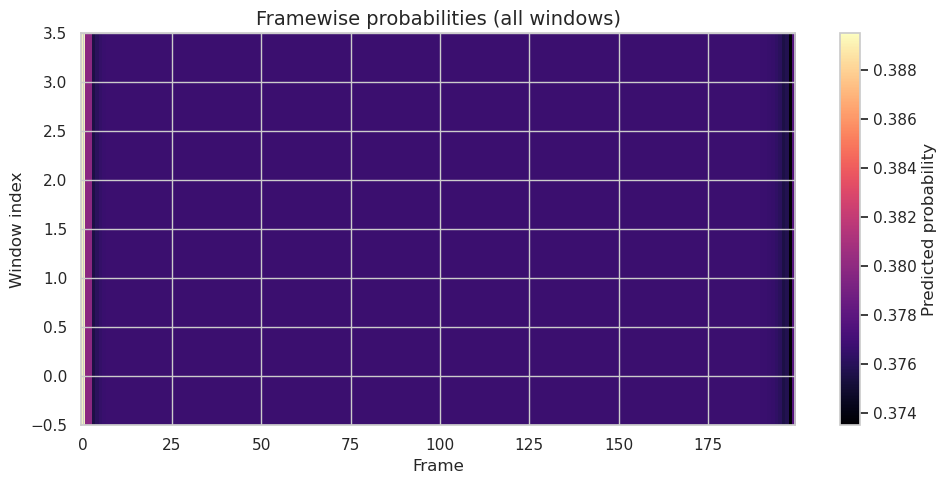

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(probs, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Predicted probability")
plt.xlabel("Frame")
plt.ylabel("Window index")
plt.title("Framewise probabilities (all windows)")
plt.tight_layout()
plt.show()

# Each row = a short time window (chunk of audio)
# Bright yellow = high swallow probability
# Dark purple = silence / background
# A clean diagonal or cluster shows consistent detection across windows.

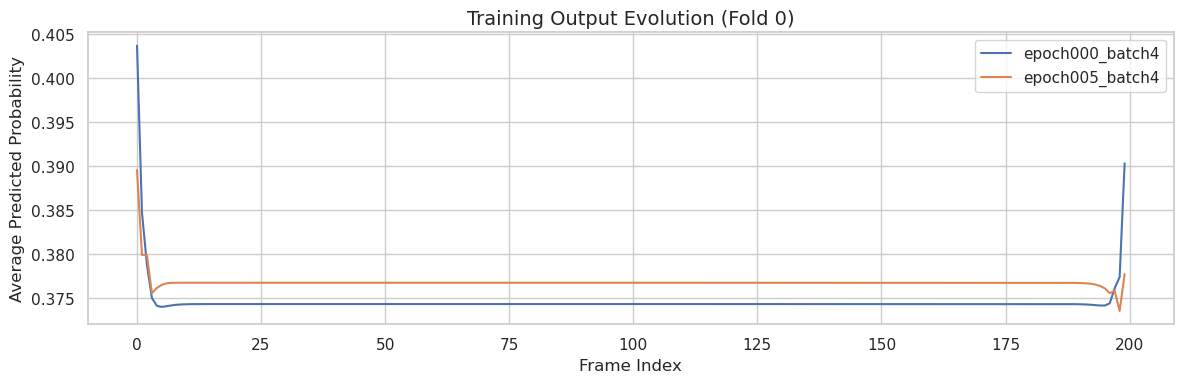

In [ ]:
# Compare epochs for one fold
trace_dir = RUNS / "swallow_count_minimal_fold0_train_20251011-200542" / "traces"
files = sorted(trace_dir.glob("epoch*_batch4.npz"))

plt.figure(figsize=(12, 4))
for f in files:
    d = np.load(f)
    probs = d["probs"].mean(axis=0)
    plt.plot(probs, label=f.stem)
plt.title("Training Output Evolution (Fold 0)")
plt.xlabel("Frame Index")
plt.ylabel("Average Predicted Probability")
plt.legend()
plt.tight_layout()
plt.show()

# Show how the model's confidence changes across epochs.

# If curves stabilize over epochs → learning converged.
# If they fluctuate wildly → unstable learning rate or undertraining.
# If later epochs shift closer to correct timing → improving temporal accuracy.

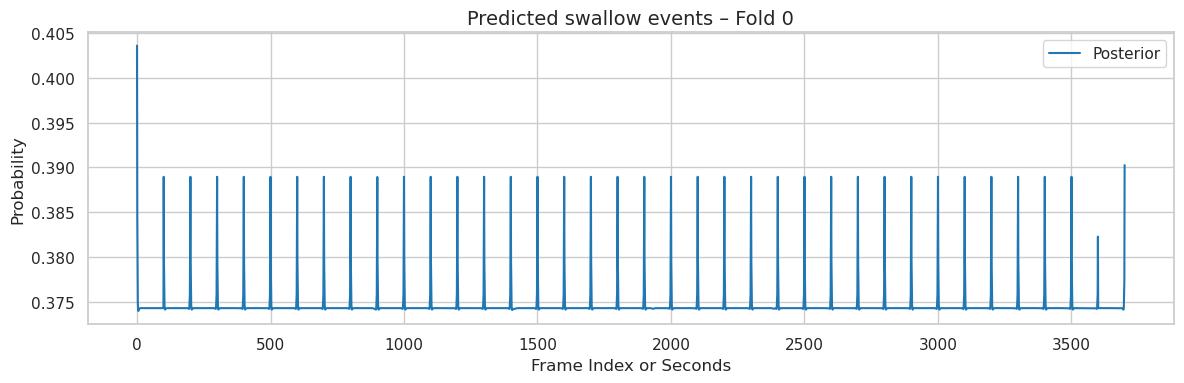

In [ ]:
# Visualize test predictions
fold = 0
test_dir = RUNS / f"minimal_fold{fold}_test"
test_file = test_dir / "1.npz"

test = np.load(test_file)
p = test["posteriors"]
onsets = test["onsets_s"]
offsets = test["offsets_s"]

plt.figure(figsize=(12, 4))
plt.plot(p, label="Posterior", color="tab:blue")
for s, e in zip(onsets, offsets):
    plt.axvspan(s, e, color="tab:red", alpha=0.3)
plt.title(f"Predicted swallow events – Fold {fold}")
plt.xlabel("Frame Index or Seconds")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize the model’s *final test predictions* on unseen data.

# Blue line: framewise confidence for swallow presence
# Red shaded regions: model’s predicted swallow intervals
# Ideally, red zones should align with actual swallows (when available).
# If red covers too much -> over-detection; too little -> under-detection.

/tmp/ipykernel_99618/412356467.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="fold", y="event_f1", data=metrics_df, palette="viridis")


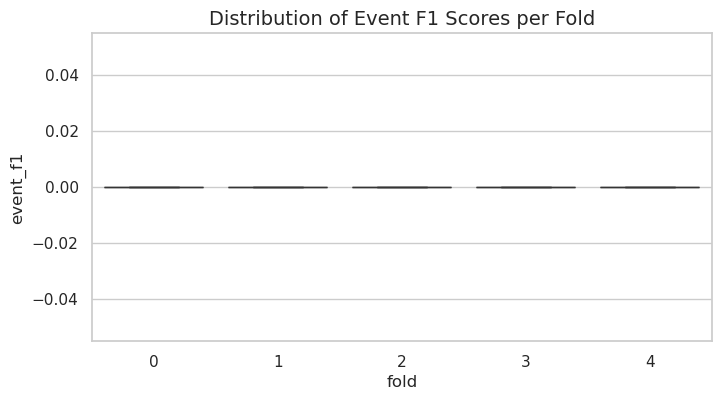

In [ ]:
# Distribution of F1 scores across folds
plt.figure(figsize=(8, 4))
sns.boxplot(x="fold", y="event_f1", data=metrics_df, palette="viridis")
plt.title("Distribution of Event F1 Scores per Fold")
plt.show()

#   Summarize model consistency across folds.

# Narrow box -> stable performance across samples.
# Wide box or outliers -> inconsistent results or noisy data.
# Fold-to-fold similarity -> model generalizes well to new participants.

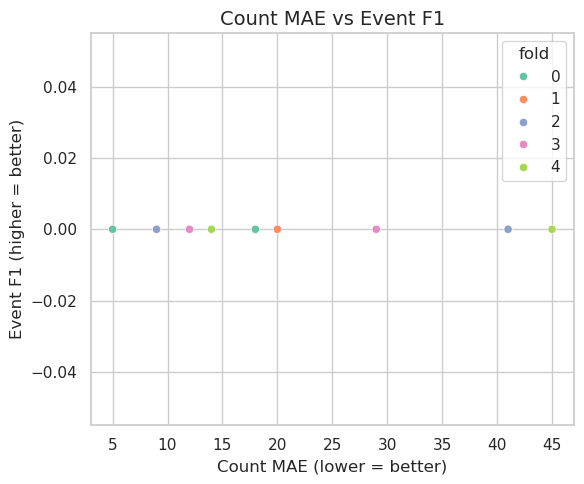

In [ ]:
# Correlation plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x="count_mae", y="event_f1", data=metrics_df, hue="fold", palette="Set2")
plt.title("Count MAE vs Event F1")
plt.xlabel("Count MAE (lower = better)")
plt.ylabel("Event F1 (higher = better)")
plt.tight_layout()
plt.show()

# Relate detection accuracy (F1) to counting accuracy (MAE).

# Bottom-right: many errors, poor F1 -> model over/under-counts heavily.
# Top-left: low error and high F1 -> model accurate both in timing and count.
# Each color = different fold; consistent clusters show stable training.

In [ ]:
# Summary table
summary = (
    metrics_df.groupby("fold")
    .agg({
        "event_f1": ["mean", "std"],
        "event_precision": "mean",
        "event_recall": "mean",
        "count_mae": "mean",
    })
)
summary.columns = ["_".join(c) for c in summary.columns]
display(summary.round(3))

#   Final summary table combining precision, recall, F1, and count metrics.

# event_f1_mean: average performance per fold
# event_f1_std: how consistent that fold was internally
# precision/recall: tradeoff between over-detecting vs missing events
# count_mae_mean: numerical accuracy of swallow counts

,event_f1_mean,event_f1_std,event_precision_mean,event_recall_mean,count_mae_mean
fold,,,,,
0,0.0,0.0,0.0,0.0,11.5
1,0.0,0.0,0.0,0.0,14.5
2,0.0,0.0,0.0,0.0,25.0
3,0.0,0.0,0.0,0.0,20.5
4,0.0,0.0,0.0,0.0,29.5
